# Reef Analysis A - Full Dataset (All Observations)


In this analysis, we use the full cleaned dataset, where each row represents an individual observation
of a reef at a specific point in time. This dataset preserves the temporal structure of the data,
including repeated measurements of the same reef across years.

The goal of this analysis is to:
- Identify dominant environmental patterns using PCA
- Explore structure and clustering in the full dataset
- Examine how reef conditions vary over time

Note:
Because some reefs are sampled more frequently than others, this dataset may overrepresent
heavily monitored reefs. Results from this analysis are therefore compared with an aggregated
reef-level dataset in Analysis B to assess the impact of sampling imbalance.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

# Load Data
df = pd.read_csv("cleaned_data/dataset_A.csv")

# Recompute feature columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
id_cols = [c for c in ["Site_ID", "Sample_ID", "year"] if c in df.columns]

feature_cols = [c for c in numeric_cols if c not in id_cols]

X = df[feature_cols].copy()

X.head()

,Latitude_Degrees,Longitude_Degrees,Distance_to_Shore,Turbidity,Cyclone_Frequency,Depth_m,Percent_Cover,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,TSA,TSA_Maximum,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMean,TSA_DHW,TSA_DHWMax
0,23.163,-82.5260,8519.23,0.0287,49.90,10.00,NaN,50.2,301.61,302.05,300.67,296.72,304.69,8.0,-0.46,1.0,-3.56,2.24,0.0,3.13,3.0,0.00,1.63,7.88,-0.80,1.83,0.00,1.09,0.0,0.00,7.25
1,-17.575,-149.7833,1431.62,0.0262,51.20,14.00,NaN,50.7,262.15,303.30,300.73,297.58,305.01,2.0,1.29,1.0,-2.73,3.10,0.5,2.77,2.0,0.26,1.48,11.41,1.29,3.00,0.25,0.93,0.0,0.26,4.65
2,18.369,-64.5640,182.33,0.0429,61.52,7.00,NaN,50.9,298.79,299.18,300.32,297.12,304.14,8.0,0.04,1.0,-2.92,2.83,16.0,4.52,3.0,0.00,2.45,16.24,-2.64,2.31,7.00,1.31,0.0,0.00,11.66
3,17.760,-64.5680,313.13,0.0424,65.39,9.02,NaN,50.9,300.16,299.61,300.38,297.25,304.07,3.0,-0.07,1.0,-2.77,2.47,22.0,4.75,3.0,0.00,2.37,16.73,-2.27,2.19,3.00,0.94,0.0,0.00,5.64
4,17.769,-64.5830,792.00,0.0424,65.39,12.50,NaN,50.9,300.15,299.70,300.38,296.63,303.76,3.0,0.00,1.0,-2.84,2.30,16.0,4.16,3.0,0.00,2.24,13.86,-2.19,1.87,3.00,1.33,0.0,0.00,6.89


In [3]:
print(df["Percent_Cover"].isna().mean())

0.3011290829525398


In [4]:
# Impute and scale data.

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

Now we can procede with PCA:

In [5]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

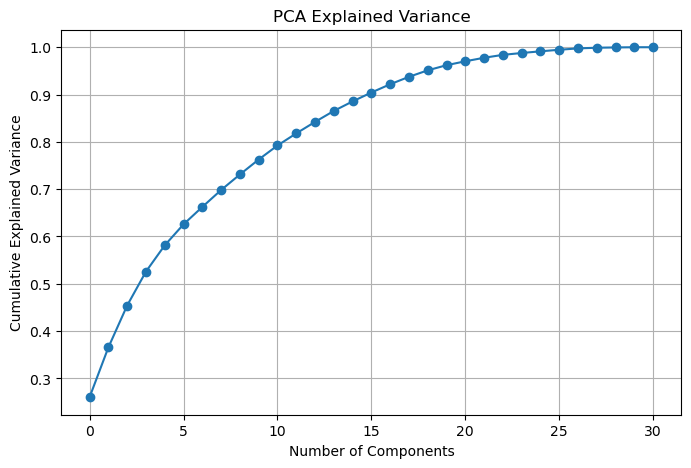

In [6]:
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_var), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

# Here Explain PCA and Plot!!!!!!

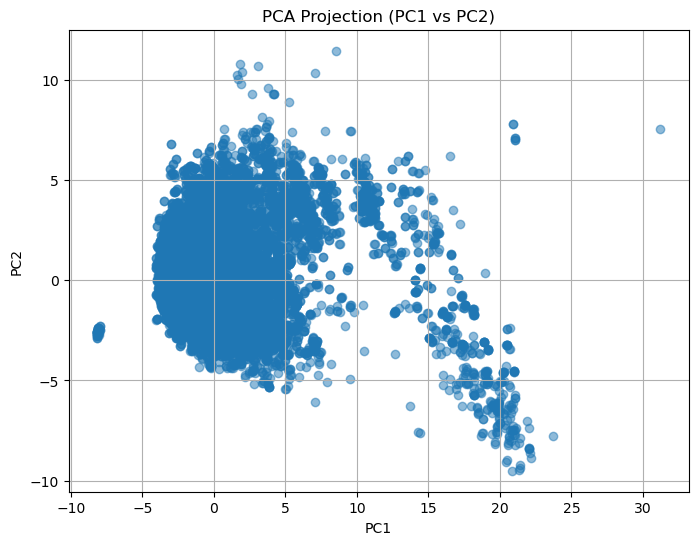

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (PC1 vs PC2)")
plt.grid(True)
plt.show()

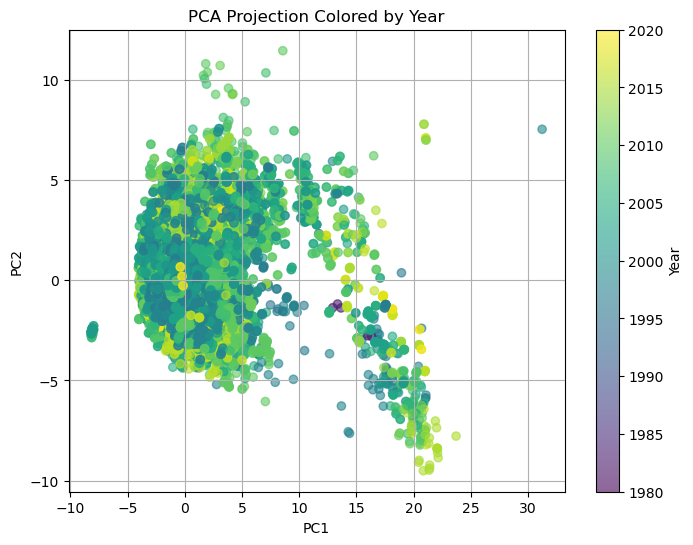

In [8]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["year"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Year")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection Colored by Year")
plt.grid(True)
plt.show()

In [9]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(feature_cols))],
    index=feature_cols
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31
Latitude_Degrees,0.032939,-0.037127,-0.148474,0.450065,0.206506,-0.374172,0.057713,0.021663,0.086482,-0.012521,0.002576,0.037831,-0.009822,-0.189625,0.146046,0.131532,-0.171881,0.046590,-0.189900,-0.366889,0.463645,-0.198526,0.089823,-0.152774,-0.111047,-0.000082,-0.035097,-0.020914,0.010553,-0.020920,0.002305
Longitude_Degrees,0.113178,0.093654,0.223403,-0.238446,-0.388567,0.016573,0.149096,-0.130083,0.138505,0.083792,-0.064665,-0.014493,-0.039054,0.196166,-0.181852,-0.442534,0.132201,-0.103212,0.046491,-0.227774,0.486447,-0.218193,0.031338,-0.070239,-0.046205,0.003543,0.068481,0.012523,0.046622,0.015143,0.003167
Distance_to_Shore,-0.003252,0.036726,-0.043784,-0.075054,-0.072827,0.376792,0.246114,0.272484,0.574356,0.145344,0.138137,0.493923,0.097732,-0.077000,0.069072,0.251249,-0.055587,0.004039,0.007985,0.006470,0.034434,-0.055751,0.040219,-0.016310,-0.001711,-0.019694,-0.032168,-0.026830,0.004010,-0.003917,0.000364
Turbidity,0.127852,0.085153,0.092713,0.254478,-0.159109,0.195838,0.131342,0.027094,-0.321436,-0.027357,-0.086735,0.070158,0.020098,0.606310,0.384380,0.308309,-0.004889,-0.154399,0.152405,-0.133360,0.012609,0.006095,0.096813,-0.005207,-0.114496,0.075437,0.000960,0.026355,-0.005029,0.008382,-0.000212
Cyclone_Frequency,-0.010051,-0.002279,-0.153571,0.254523,0.132983,-0.262489,0.064897,0.247671,0.395161,-0.135115,-0.459833,-0.071157,0.100131,0.355207,-0.322873,-0.074294,0.129594,-0.218537,0.096779,0.177400,-0.109686,0.025700,0.024482,0.050788,0.001399,0.017391,0.027916,0.003212,-0.010516,-0.006472,-0.000733


In [10]:
loadings["PC1"].sort_values(key=abs, ascending=False).head(10)

SSTA_DHW_Standard_Deviation         0.329010
SSTA_Standard_Deviation             0.309623
SSTA_FrequencyMean                  0.309048
SSTA_DHWMax                         0.285547
TSA_DHWMax                          0.279155
TSA_FrequencyMean                   0.263793
SSTA_Maximum                        0.232320
TSA_Maximum                         0.225969
TSA_Frequency                       0.221961
TSA_Frequency_Standard_Deviation    0.214800
Name: PC1, dtype: float64

In [11]:
loadings["PC2"].sort_values(key=abs, ascending=False).head(10)

Temperature_Kelvin    -0.458157
TSA                   -0.406724
Temperature_Mean      -0.371997
Temperature_Minimum   -0.336803
SSTA                  -0.253170
Windspeed              0.227663
TSA_DHW               -0.200384
SSTA_DHW              -0.176658
TSA_Frequency         -0.168124
Temperature_Maximum   -0.147489
Name: PC2, dtype: float64

c:\Users\gaery\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


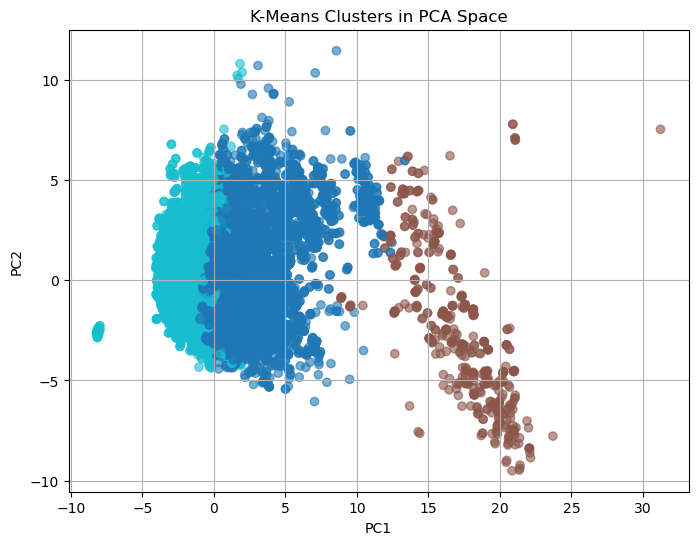

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca[:, :5])  # use top PCs

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in PCA Space")
plt.grid(True)
plt.show()